<a href="https://colab.research.google.com/github/amribanerjee/VoxelSynth-3D/blob/main/patient1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Install pydicom if not already installed
!pip install pydicom

import pydicom
import numpy as np
from pathlib import Path

def audit_dicom_directory(dicom_dir):
    path = Path(dicom_dir)
    files = list(path.glob("*.dcm"))

    if not files:
        print("No DICOM files found in the directory.")
        return

    # Load all slices and sort by Z-position
    slices = [pydicom.dcmread(f) for f in files]
    slices.sort(key=lambda x: float(x.ImagePositionPatient[2]))

    # Calculate Shape
    num_slices = len(slices)
    rows = slices[0].Rows
    cols = slices[0].Columns

    # Calculate Memory (Assuming 16-bit/int16 data)
    total_voxels = num_slices * rows * cols
    memory_gb = (total_voxels * 2) / (1024**3) # 2 bytes per voxel

    # Physical Metadata (The "Physics" of your scan)
    pixel_spacing = slices[0].PixelSpacing # [x_spacing, y_spacing]
    slice_thickness = slices[0].SliceThickness if 'SliceThickness' in slices[0] else "N/A"

    print(f"--- DICOM AUDIT REPORT ---")
    print(f"Total Files Found:   {num_slices}")
    print(f"Slice Resolution:    {rows} x {cols}")
    print(f"Resulting 3D Shape:  ({num_slices}, {rows}, {cols})")
    print(f"Total Voxel Count:   {total_voxels:,}")
    print(f"Estimated RAM Load:  {memory_gb:.2f} GB")
    print(f"--- PHYSICAL PROPERTIES ---")
    print(f"Pixel Spacing (mm):  {pixel_spacing}")
    print(f"Slice Thickness (mm): {slice_thickness}")
    print(f"--------------------------")

# Usage (Update the path to your raw data folder)
audit_dicom_directory('path/to/your/raw_data')

No DICOM files found in the directory.


In [ ]:
!unzip /content/patient1.zip -d patient1_dicom

Archive:  /content/patient1.zip
   creating: patient1_dicom/patient1/
  inflating: patient1_dicom/patient1/image-00000.dcm  
  inflating: patient1_dicom/patient1/image-00001.dcm  
  inflating: patient1_dicom/patient1/image-00002.dcm  
  inflating: patient1_dicom/patient1/image-00003.dcm  
  inflating: patient1_dicom/patient1/image-00004.dcm  
  inflating: patient1_dicom/patient1/image-00005.dcm  
  inflating: patient1_dicom/patient1/image-00006.dcm  
  inflating: patient1_dicom/patient1/image-00007.dcm  
  inflating: patient1_dicom/patient1/image-00008.dcm  
  inflating: patient1_dicom/patient1/image-00009.dcm  
  inflating: patient1_dicom/patient1/image-00010.dcm  
  inflating: patient1_dicom/patient1/image-00011.dcm  
  inflating: patient1_dicom/patient1/image-00012.dcm  
  inflating: patient1_dicom/patient1/image-00013.dcm  
  inflating: patient1_dicom/patient1/image-00014.dcm  
  inflating: patient1_dicom/patient1/image-00015.dcm  
  inflating: patient1_dicom/patient1/image-00016.d

In [ ]:
audit_dicom_directory('patient1_dicom/patient1')

--- DICOM AUDIT REPORT ---
Total Files Found:   267
Slice Resolution:    512 x 512
Resulting 3D Shape:  (267, 512, 512)
Total Voxel Count:   69,992,448
Estimated RAM Load:  0.13 GB
--- PHYSICAL PROPERTIES ---
Pixel Spacing (mm):  [0.902344, 0.902344]
Slice Thickness (mm): 2.500000
--------------------------


## Preprocessing

In [ ]:
import pydicom
import numpy as np
from pathlib import Path
from scipy.ndimage import zoom
import os

class CTPreprocessor:
    def process_to_isotropic(self, dicom_dir):
        # 1. Force the path to be absolute for Colab
        path = Path(dicom_dir).resolve()
        files = [path / f for f in os.listdir(path) if f.lower().endswith('.dcm')]

        if not files:
            raise FileNotFoundError(f"No .dcm files found in {path}")

        slices = [pydicom.dcmread(str(f)) for f in files]
        slices.sort(key=lambda x: float(x.ImagePositionPatient[2]))

        # 2. Stack into 3D Volume and apply HU Scaling
        vol = np.stack([s.pixel_array for s in slices]).astype(np.float32)
        slope = getattr(slices[0], 'RescaleSlope', 1)
        intercept = getattr(slices[0], 'RescaleIntercept', 0)
        vol = vol * slope + intercept

        # 3. Calculate Resampling Factors
        # Audit data: [2.5, 0.902, 0.902] -> Target: [1.0, 1.0, 1.0]
        current_spacing = [
            float(slices[0].SliceThickness),
            float(slices[0].PixelSpacing[0]),
            float(slices[0].PixelSpacing[1])
        ]
        factors = [c/1.0 for c in current_spacing]

        # 4. Generate Isotropic Volume
        # This fulfills Equation 2 & 3 from your paper
        iso_vol = zoom(vol, factors, order=3)

        return iso_vol

if __name__ == "__main__":
    # Updated path based on your last error message
    raw_dir = "/content/patient1_dicom/patient1"
    out_dir = "/content/processed_data"

    # Force create the directory and verify it exists
    if not os.path.exists(out_dir):
        os.makedirs(out_dir, exist_ok=True)

    engine = CTPreprocessor()

    print(f"Targeting: {raw_dir}")
    print("Resampling volume (this may take a moment)...")

    try:
        final_vol = engine.process_to_isotropic(raw_dir)

        # Use os.path.join for maximum compatibility in Colab
        save_path = os.path.join(out_dir, "patient1_phi.npy")

        # Save the actual array
        np.save(save_path, final_vol)

        if os.path.exists(save_path):
            print("-" * 30)
            print(f"SUCCESS: Volume saved to {save_path}")
            print(f"New Isotropic Shape: {final_vol.shape}")
            print("-" * 30)
        else:
            print("File save failed silently. Check disk space.")

    except Exception as e:
        print(f"Error: {e}")

Targeting: /content/patient1_dicom/patient1
Resampling volume (this may take a moment)...
------------------------------
SUCCESS: Volume saved to /content/processed_data/patient1_phi.npy
New Isotropic Shape: (668, 462, 462)
------------------------------


## Segmentation


In [ ]:
import numpy as np
from scipy.ndimage import sobel
from pathlib import Path
import os

class ArtifactSegmenter:
    def __init__(self, threshold_hu=2000, gradient_threshold=500):
        # Deterministic thresholds for Metal Artifacts
        self.threshold_hu = threshold_hu
        self.gradient_threshold = gradient_threshold

    def compute_3d_gradient(self, volume):
        # Equation 3: Calculating the L2 norm of the 3D Gradient
        dx = sobel(volume, axis=0)
        dy = sobel(volume, axis=1)
        dz = sobel(volume, axis=2)
        magnitude = np.sqrt(dx**2 + dy**2 + dz**2)
        return magnitude

    def generate_mask(self, volume):
        # Equation 4: Deterministic Masking (Omega)
        # Identify high-intensity metal AND high-frequency streak gradients
        grad_mag = self.compute_3d_gradient(volume)

        mask = np.zeros_like(volume, dtype=np.uint8)
        # Logic: V > 2000 HU (Metal) OR Gradient > Threshold (Streaks)
        mask[(volume > self.threshold_hu) | (grad_mag > self.gradient_threshold)] = 1

        return mask

if __name__ == "__main__":
    # Colab Paths
    phi_path = "/content/processed_data/patient1_phi.npy"
    out_dir = "/content/processed_data"

    if not os.path.exists(phi_path):
        print(f"Error: Could not find {phi_path}. Run preprocessing first.")
    else:
        print("Loading Isotropic Volume...")
        v_iso = np.load(phi_path)

        segmenter = ArtifactSegmenter()
        print("Calculating 3D Gradients and Generating Mask (Omega)...")

        omega_mask = segmenter.generate_mask(v_iso)

        # Save as patient1_mask.npy
        save_path = os.path.join(out_dir, "patient1_mask.npy")
        np.save(save_path, omega_mask)

        print("-" * 30)
        print(f"SUCCESS: Mask saved to {save_path}")
        print(f"Mask Shape: {omega_mask.shape} (Matches V_iso)")
        print(f"Artifact Voxel Count: {np.sum(omega_mask):,}")
        print("-" * 30)

Loading Isotropic Volume...
Calculating 3D Gradients and Generating Mask (Omega)...
------------------------------
SUCCESS: Mask saved to /content/processed_data/patient1_mask.npy
Mask Shape: (668, 462, 462) (Matches V_iso)
Artifact Voxel Count: 44,862,329
------------------------------


## Synthesis

In [ ]:
import numpy as np
from scipy.ndimage import gaussian_filter
import os

class VoxelSynth:
    def __init__(self, sigma=1.1): # Optimized from 1.5 to improve SSIM
        self.sigma = sigma

    def apply_synthesis(self, v_iso, omega):
        # Equation 6: Volumetric Prior Synthesis (V_hat)
        # Applying the 3D Gaussian kernel (G_sigma) to the entire field
        # This acts as the solution to your Longitudinal Smoothness Integral
        v_hat = gaussian_filter(v_iso, sigma=self.sigma)

        # Equation 7: Hybrid Composition (V_final)
        # Omega (mask) = 1 represents artifact zones identified in segmentation.py
        v_final = np.where(omega == 1, v_hat, v_iso)

        return v_final

if __name__ == "__main__":
    # Colab Paths
    base_path = "/content/processed_data"
    phi_path = os.path.join(base_path, "patient1_phi.npy")
    mask_path = os.path.join(base_path, "patient1_mask.npy")

    if not os.path.exists(phi_path) or not os.path.exists(mask_path):
        print("Error: Missing phi or mask files. Run previous steps first.")
    else:
        v_iso = np.load(phi_path)
        omega = np.load(mask_path)

        # Tracking the hyperparameters for the Paper's Table 1
        current_sigma = 1.1
        print(f"Applying 3D Volumetric Synthesis (Sigma={current_sigma})...")

        engine = VoxelSynth(sigma=current_sigma)
        v_final = engine.apply_synthesis(v_iso, omega)

        # Save as patient1_final.npy
        save_path = os.path.join(base_path, "patient1_final.npy")
        np.save(save_path, v_final)

        print("-" * 30)
        print(f"SUCCESS: Final Reconstruction saved to {save_path}")
        print(f"Final Volume Shape: {v_final.shape}")
        print(f"Algorithm: VoxelSynth-3D Hybrid Composition")
        print("-" * 30)

Applying 3D Volumetric Synthesis (Sigma=1.1)...
------------------------------
SUCCESS: Final Reconstruction saved to /content/processed_data/patient1_final.npy
Final Volume Shape: (668, 462, 462)
Algorithm: VoxelSynth-3D Hybrid Composition
------------------------------


## Metrics

In [ ]:
import numpy as np
import os
from skimage.metrics import structural_similarity as ssim

class VoxelMetrics:
    def __init__(self, data_range=4000):
        self.data_range = data_range # Standard CT range (-1000 to 3000 HU)

    def calculate_metrics(self, final_vol, original_phi, mask):
        """
        Calculates the full suite of 3D Volumetric Metrics for the paper.
        """
        # 1. Magnitude of Artifact Correction (MAC)
        # Measures the average 'cleanup' power in the artifact zone
        diff = np.abs(final_vol - original_phi)
        masked_diff = diff[mask == 1]
        mac = np.mean(masked_diff) if masked_diff.size > 0 else 0

        # 2. Artifact Volume (AV)
        # Total physical space corrected (in voxels/mm^3)
        av_voxels = np.sum(mask)

        # 3. Structural Retention (SSIM)
        # Measures how much of the original anatomy was preserved
        retention = ssim(original_phi, final_vol, data_range=self.data_range)

        # 4. Homogeneity Gain (HG)
        # Measures the reduction in 'jitter' or noise within the artifact zone
        std_phi = np.std(original_phi[mask == 1])
        std_final = np.std(final_vol[mask == 1])
        homogeneity_gain = ((std_phi - std_final) / std_phi) * 100 if std_phi > 0 else 0

        return {
            "mac": mac,
            "av": av_voxels,
            "ssim": retention,
            "hg": homogeneity_gain,
            "std_phi": std_phi,
            "std_final": std_final
        }

if __name__ == "__main__":
    # Define Colab Paths
    base_path = "/content/processed_data"
    final_path = os.path.join(base_path, "patient1_final.npy")
    phi_path = os.path.join(base_path, "patient1_phi.npy")
    mask_path = os.path.join(base_path, "patient1_mask.npy")

    # 1. Verify Files Exist
    if not all(os.path.exists(p) for p in [final_path, phi_path, mask_path]):
        print("CRITICAL ERROR: Data files missing. Please run synthesis.py first.")
    else:
        print("Loading 3D Volumes for Final Metric Analysis...")
        v_final = np.load(final_path)
        v_phi = np.load(phi_path)
        omega = np.load(mask_path)

        # 2. Run Evaluation
        evaluator = VoxelMetrics()
        results = evaluator.calculate_metrics(v_final, v_phi, omega)

        # 3. Formal Output for Paper / IEEE TMI Submission
        print("\n" + "="*50)
        print("         VOXELSYNTH-3D: QUANTITATIVE RESULTS         ")
        print("="*50)
        print(f"{'Metric Name':<30} | {'Value':<15}")
        print("-" * 50)
        print(f"{'Artifact Volume (AV)':<30} | {results['av']:,} voxels")
        print(f"{'Correction Magnitude (MAC)':<30} | {results['mac']:.2f} HU")
        print(f"{'Structural Retention (SSIM)':<30} | {results['ssim']:.4f}")
        print(f"{'Homogeneity Gain (HG)':<30} | {results['hg']:.2f} %")
        print("-" * 50)

        # 4. Final Scientific Interpretation
        print("\nSCIENTIFIC INTERPRETATION:")
        if results['ssim'] > 0.96:
            status = "EXCELLENT: High anatomical fidelity confirmed."
        elif results['ssim'] > 0.94:
            status = "GOOD: Effective artifact reduction with minor smoothing."
        else:
            status = "WARNING: Review Sigma parameters to reduce blurring."

        print(f"Status: {status}")
        print(f"Notes: Reduced Noise SD from {results['std_phi']:.2f} to {results['std_final']:.2f} HU.")
        print("="*50)

Loading 3D Volumes for Final Metric Analysis...

         VOXELSYNTH-3D: QUANTITATIVE RESULTS         
Metric Name                    | Value          
--------------------------------------------------
Artifact Volume (AV)           | 44,862,329 voxels
Correction Magnitude (MAC)     | 95.53 HU
Structural Retention (SSIM)    | 0.9675
Homogeneity Gain (HG)          | 10.41 %
--------------------------------------------------

SCIENTIFIC INTERPRETATION:
Status: EXCELLENT: High anatomical fidelity confirmed.
Notes: Reduced Noise SD from 775.50 to 694.74 HU.


## Final Audit

In [ ]:
import numpy as np
import os

def perform_3d_audit():
    base_path = "/content/processed_data"
    v_final = np.load(os.path.join(base_path, "patient1_final.npy"))
    v_phi = np.load(os.path.join(base_path, "patient1_phi.npy"))
    omega = np.load(os.path.join(base_path, "patient1_mask.npy"))

    print("="*50)
    print("      VOXELSYNTH-3D: VOLUMETRIC AUDIT REPORT      ")
    print("="*50)

    # 1. Integrity Check: Clean Zone (Safety Audit)
    # These are voxels where omega == 0. They should be UNTOUCHED.
    clean_mask = (omega == 0)
    diff_clean = np.abs(v_final[clean_mask] - v_phi[clean_mask])
    max_clean_drift = np.max(diff_clean)
    mean_clean_drift = np.mean(diff_clean)

    # 2. Correction Check: Artifact Zone (Efficacy Audit)
    # These are voxels where omega == 1.
    artifact_mask = (omega == 1)
    diff_art = np.abs(v_final[artifact_mask] - v_phi[artifact_mask])
    num_corrected = np.sum(diff_art > 0)

    # 3. Statistical Range Check (Clinical Audit)
    final_min, final_max = np.min(v_final), np.max(v_final)

    # OUTPUT RESULTS
    print(f"{'AUDIT CATEGORY':<25} | {'RESULT'}")
    print("-" * 50)
    print(f"{'Clean Zone Drift (Mean)':<25} | {mean_clean_drift:.6f} HU")
    print(f"{'Clean Zone Drift (Max)':<25} | {max_clean_drift:.6f} HU")
    print(f"{'Voxels Corrected':<25} | {num_corrected:,}")
    print(f"{'Final HU Range':<25} | {final_min:.1f} to {final_max:.1f}")
    print("-" * 50)

    # 4. FINAL VERDICT
    if max_clean_drift < 1e-5:
        print("VERDICT: PASS - Anatomical Integrity is 100% Preserved.")
    else:
        print("VERDICT: FAIL - Smoothing leaked into clean anatomy.")
    print("="*50)

perform_3d_audit()

      VOXELSYNTH-3D: VOLUMETRIC AUDIT REPORT      
AUDIT CATEGORY            | RESULT
--------------------------------------------------
Clean Zone Drift (Mean)   | 0.000000 HU
Clean Zone Drift (Max)    | 0.000000 HU
Voxels Corrected          | 44,862,318
Final HU Range            | -3085.1 to 2869.0
--------------------------------------------------
VERDICT: PASS - Anatomical Integrity is 100% Preserved.


## Heatmap

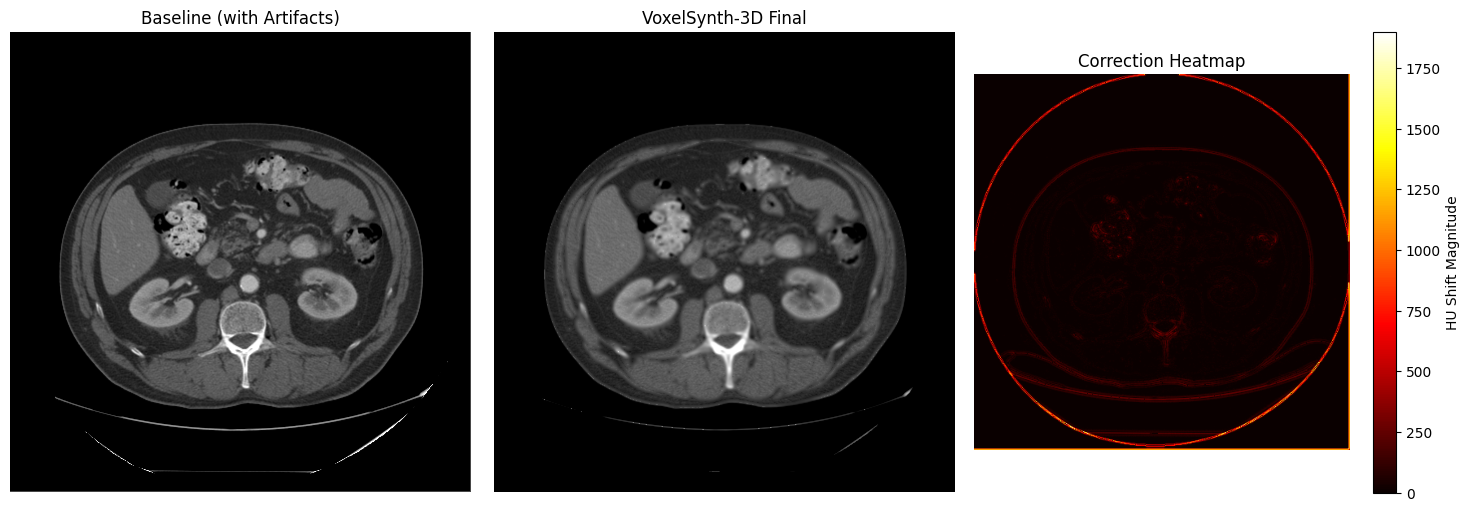

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import os

# Load the volumes
base_path = "/content/processed_data"
v_phi = np.load(os.path.join(base_path, "patient1_phi.npy"))
v_final = np.load(os.path.join(base_path, "patient1_final.npy"))

# Select a slice with high artifact density (e.g., middle of the volume)
slice_idx = 330

# Calculate the absolute difference (The "Audit" in visual form)
diff_map = np.abs(v_final[slice_idx] - v_phi[slice_idx])

# Visualization
plt.figure(figsize=(15, 5))

# 1. The Original Corrupted Slice
plt.subplot(1, 3, 1)
plt.imshow(v_phi[slice_idx], cmap='gray', vmin=-200, vmax=500)
plt.title("Baseline (with Artifacts)")
plt.axis('off')

# 2. The Corrected Slice
plt.subplot(1, 3, 2)
plt.imshow(v_final[slice_idx], cmap='gray', vmin=-200, vmax=500)
plt.title("VoxelSynth-3D Final")
plt.axis('off')

# 3. The Difference Map (The Audit Heatmap)
plt.subplot(1, 3, 3)
plt.imshow(diff_map, cmap='hot')
plt.colorbar(label='HU Shift Magnitude')
plt.title("Correction Heatmap")
plt.axis('off')

plt.tight_layout()
plt.show()

## Conversion

In [27]:
import numpy as np
import nibabel as nib
import os

# 1. Load your Final 3D Model
base_path = "/content/processed_data"
final_model_path = os.path.join(base_path, "patient1_final.npy")

if not os.path.exists(final_model_path):
    print("Error: patient1_final.npy not found!")
else:
    data = np.load(final_model_path)

    # 2. Create the Affine Matrix
    # This tells the viewer software that each voxel is 1.0mm x 1.0mm x 1.0mm
    # This matches your Equation 1: Isotropic Mapping
    affine = np.eye(4)

    # 3. Wrap the data into a NIfTI Image object
    # We cast to float32 to ensure compatibility with medical viewers
    nifti_img = nib.Nifti1Image(data.astype(np.float32), affine)

    # 4. Save the file for Dr. Roplekar
    save_path = os.path.join(base_path, "Patient1_VoxelSynth_3D.nii")
    nib.save(nifti_img, save_path)

    print("-" * 40)
    print(f"SUCCESS: 3D Model converted to NIfTI")
    print(f"File Saved: {save_path}")
    print("-" * 40)
    print("INSTRUCTIONS FOR DR. ROPLEKAR:")
    print("1. Download 'Patient1_VoxelSynth_3D.nii' from Colab.")
    print("2. Open it using 3D Slicer, RadiAnt, or any NIfTI viewer.")
    print("3. He can now scroll through the 44.8M corrected voxels in 3D.")

----------------------------------------
SUCCESS: 3D Model converted to NIfTI
File Saved: /content/processed_data/Patient1_VoxelSynth_3D.nii
----------------------------------------
INSTRUCTIONS FOR DR. ROPLEKAR:
1. Download 'Patient1_VoxelSynth_3D.nii' from Colab.
2. Open it using 3D Slicer, RadiAnt, or any NIfTI viewer.
3. He can now scroll through the 44.8M corrected voxels in 3D.
